In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Rows: {data.shape[0]}')
print(f'Columns: {data.shape[1]}')
print(f'Duplicates: {data.duplicated().sum()}')

Rows: 7043
Columns: 21
Duplicates: 0


In [3]:
data.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
print(f'Amount of TotalCharges == " ": {data["TotalCharges"].str.isspace().sum()}')
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
print(f'Amount of NaN after conversion: {data["TotalCharges"].isna().sum()}')

data['TotalCharges'] = data['TotalCharges'].fillna(0).astype("float64")

data['SeniorCitizen'] = data['SeniorCitizen'].astype(str)

del data['customerID']

Amount of TotalCharges == " ": 11
Amount of NaN after conversion: 11


In [6]:
data.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [7]:
data.describe(include='object')

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,Male,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,3555,5901,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


In [8]:
(data['Churn'].value_counts(normalize=True) * 100).round(2).astype(str) + " %"

Churn
No     73.46 %
Yes    26.54 %
Name: proportion, dtype: object

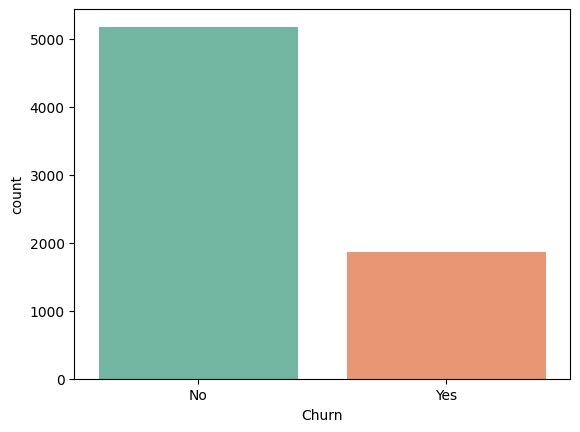

In [15]:
sns.countplot(data, x=data['Churn'], hue=data['Churn'], legend=False, palette='Set2')
plt.show()

In [9]:
cat_cols = list(data.drop(['Churn'], axis=1).select_dtypes(include='object').columns)
num_cols = list(data.select_dtypes(include='number').columns)

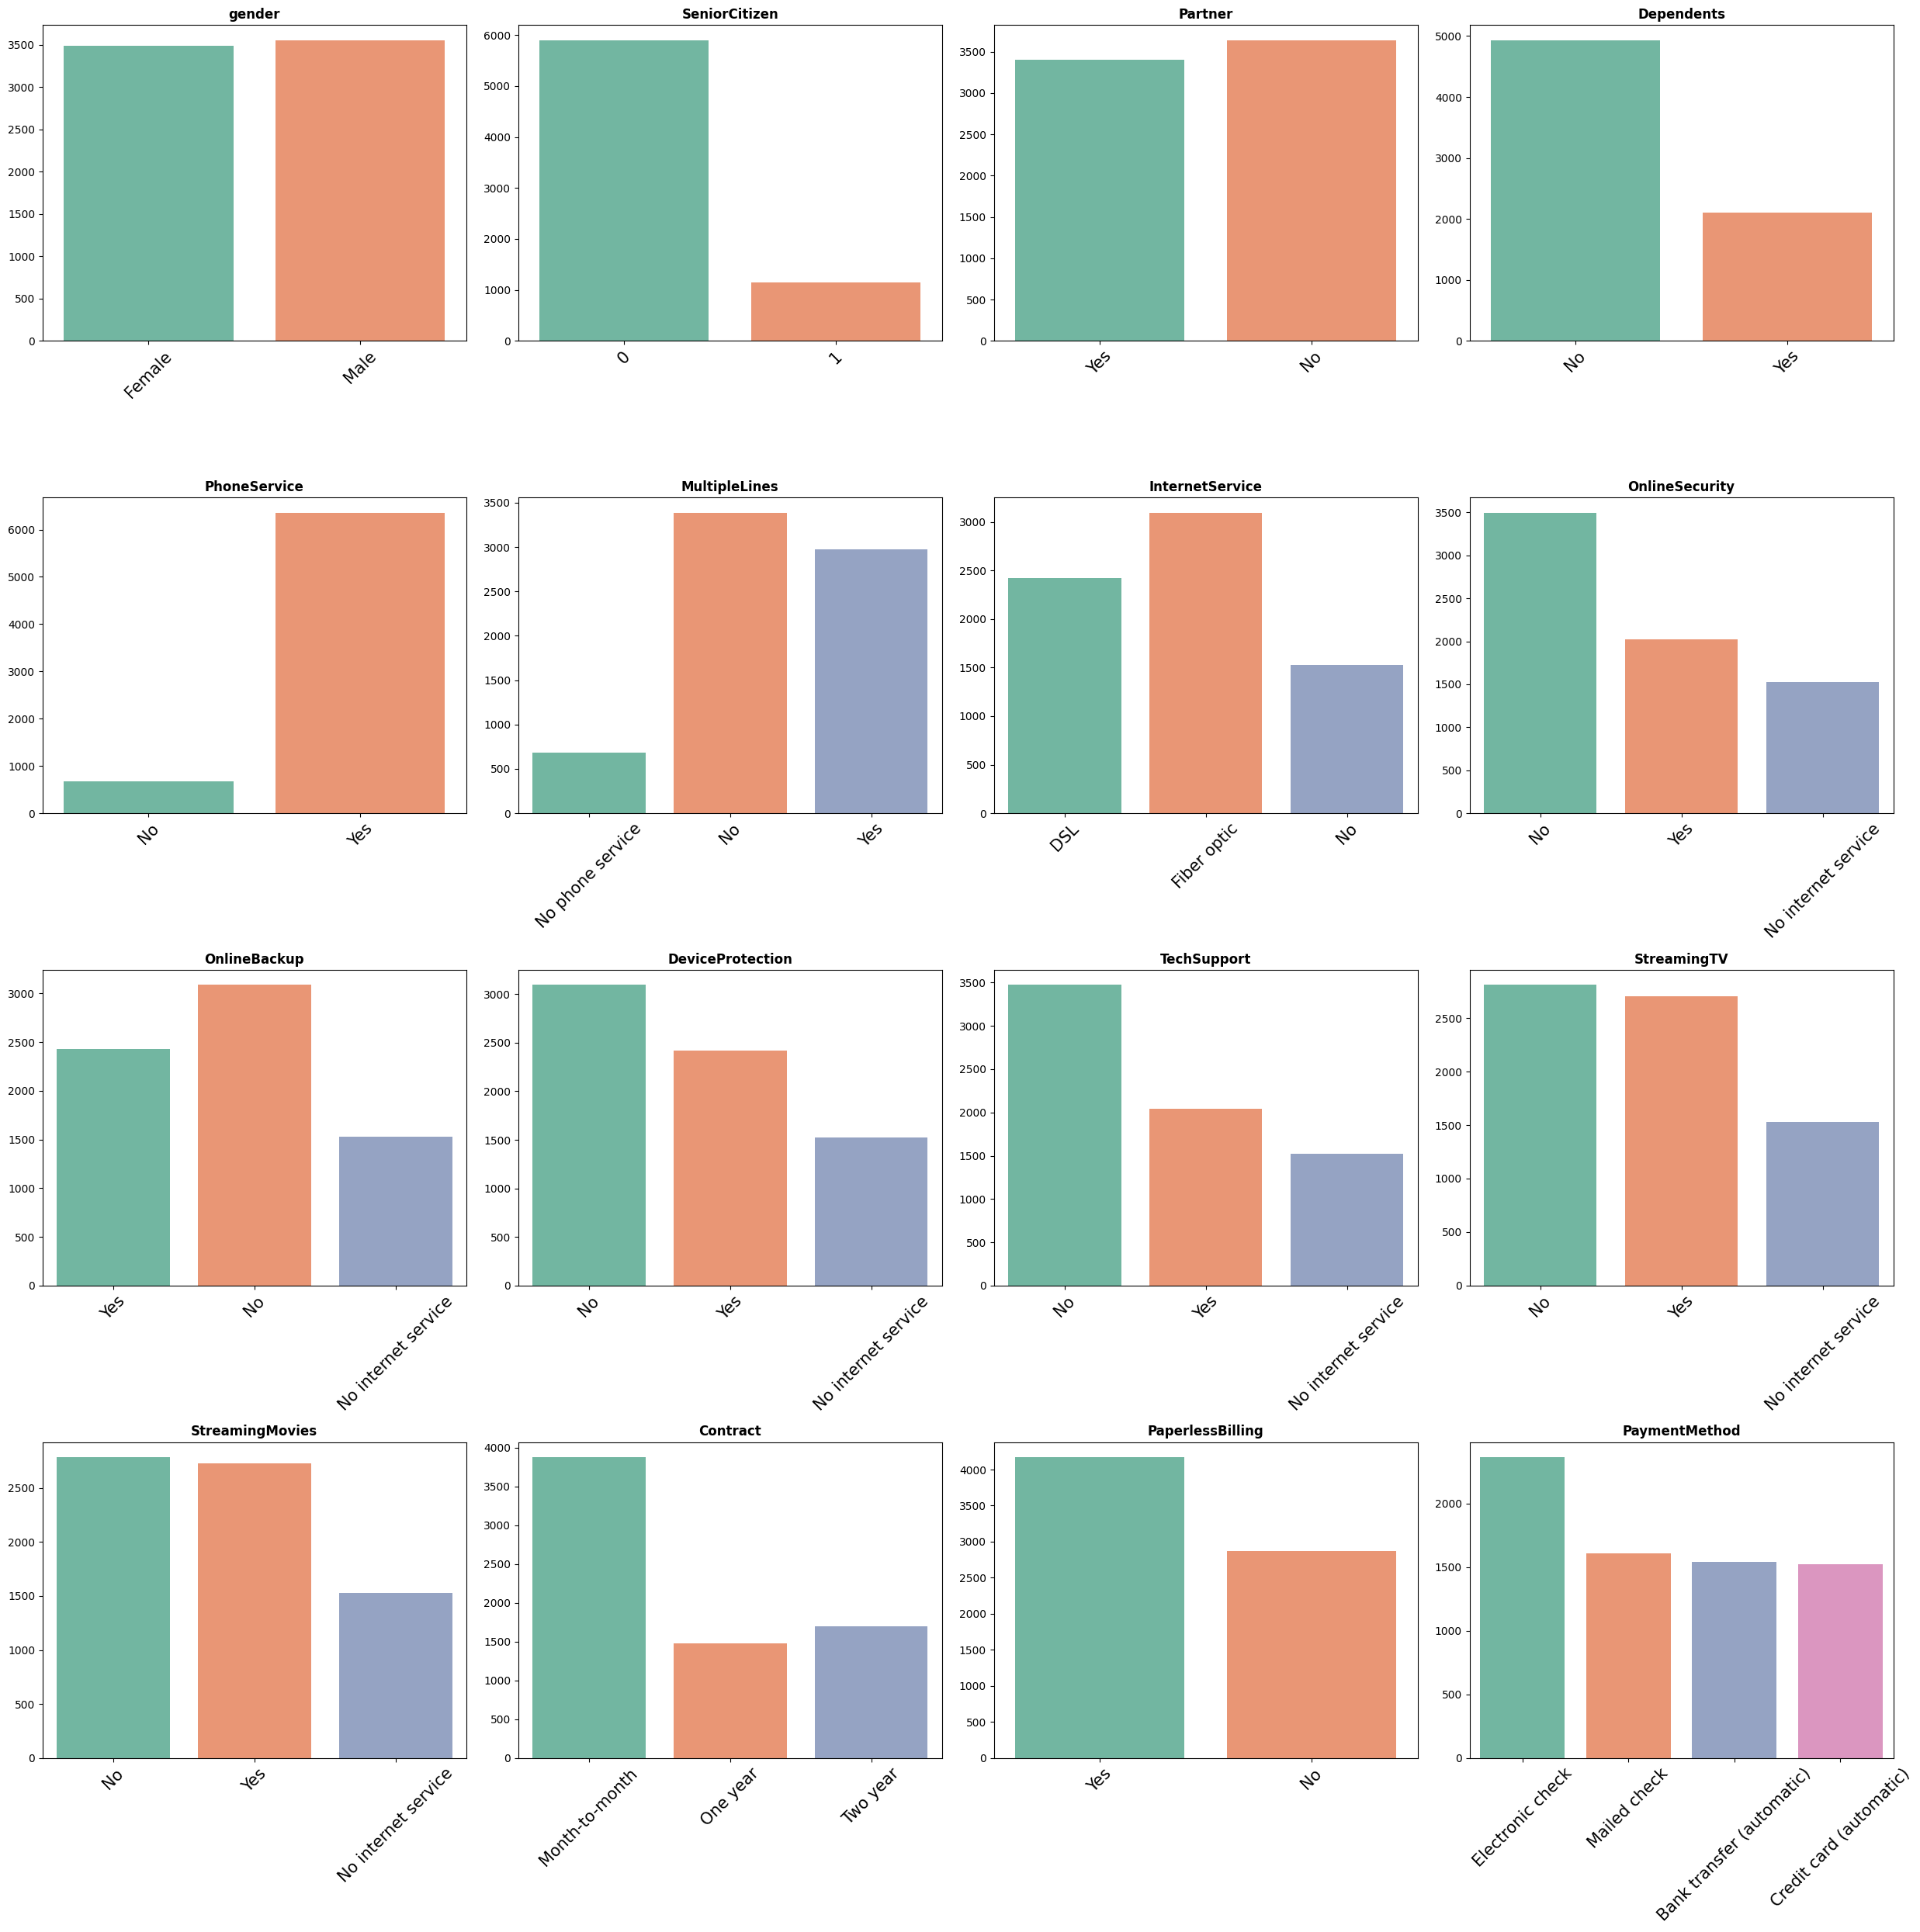

In [11]:
fig, axes = plt.subplots(4, 4, figsize=(25, 25))
axes_flat = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=data, x=col, ax=axes_flat[i], hue=col, legend=False, palette='Set2')
    axes_flat[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes_flat[i].set_xlabel('')
    axes_flat[i].set_ylabel('')

    axes_flat[i].tick_params(axis='x', rotation=45, labelsize=15)
    
for j in range(len(cat_cols), len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.tight_layout()
plt.show()

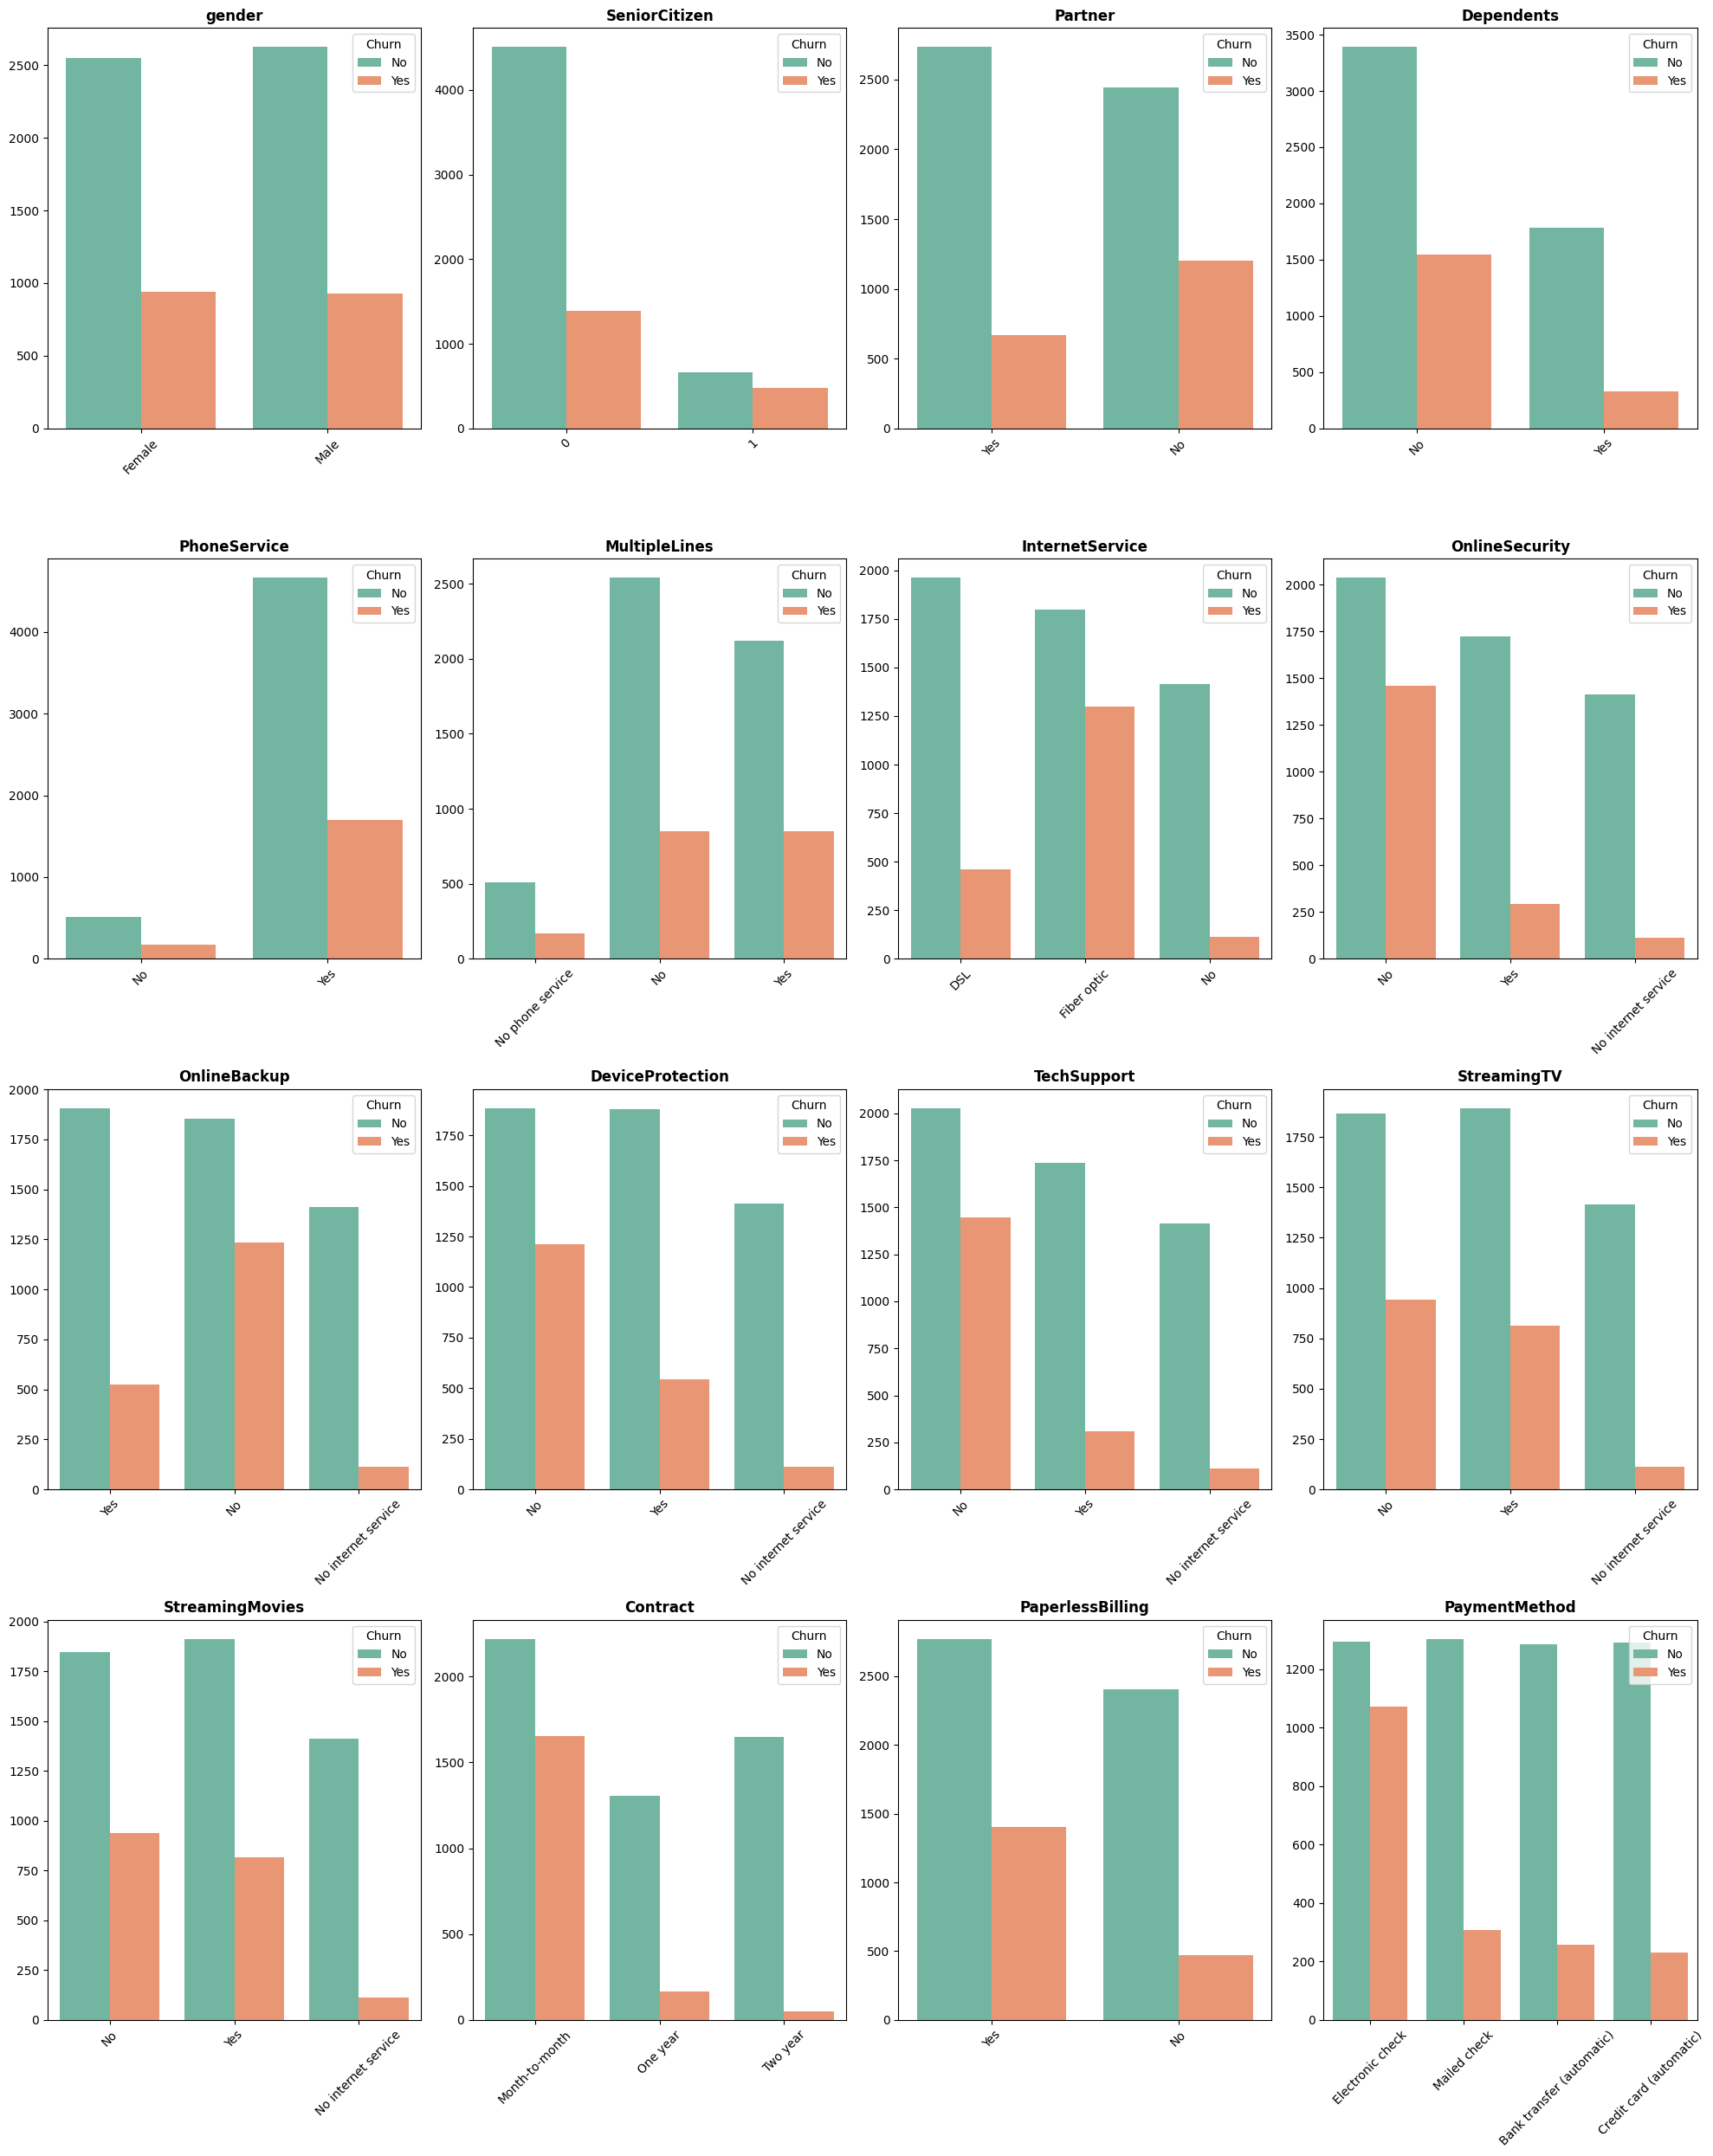

In [12]:
fig, ax = plt.subplots(4, 4, figsize=(20, 25))
axes_flat = ax.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=data, x=col, hue='Churn', ax=axes_flat[i], palette='Set2')
    axes_flat[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes_flat[i].set_xlabel('')
    axes_flat[i].set_ylabel('')

    axes_flat[i].tick_params(axis='x', rotation=45, labelsize=10)

for j in range(len(cat_cols), len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.tight_layout()
plt.show()

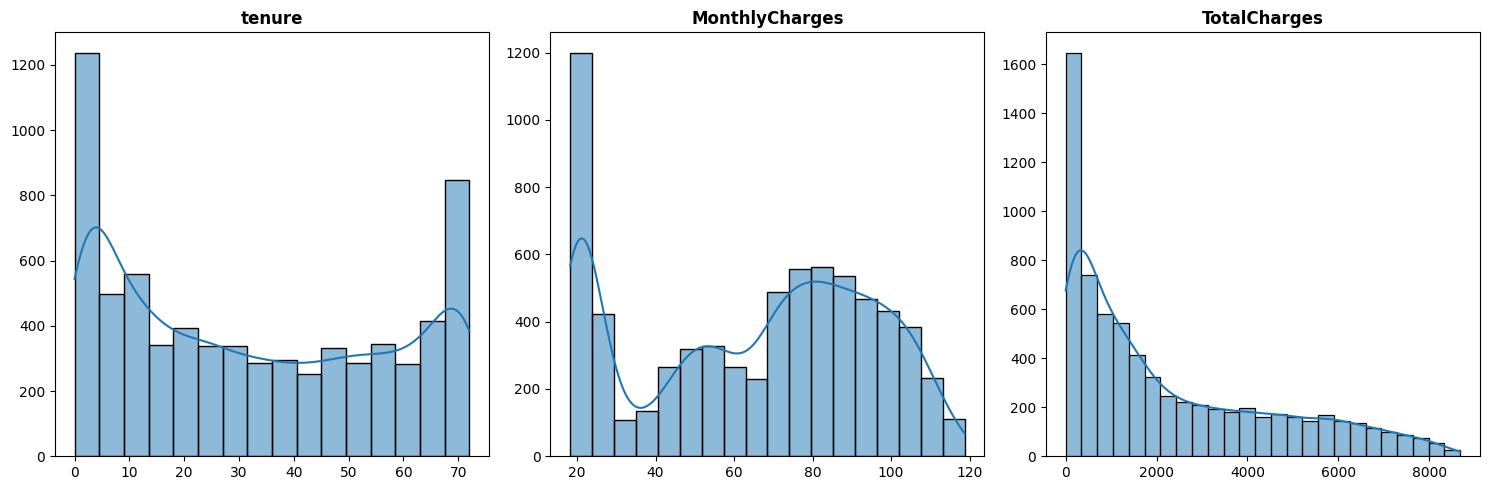

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
axes_flat = ax.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=data, x=col, ax=axes_flat[i], kde=True)
    axes_flat[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes_flat[i].set_xlabel('')
    axes_flat[i].set_ylabel('')

for j in range(len(num_cols), len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.tight_layout()
plt.show()

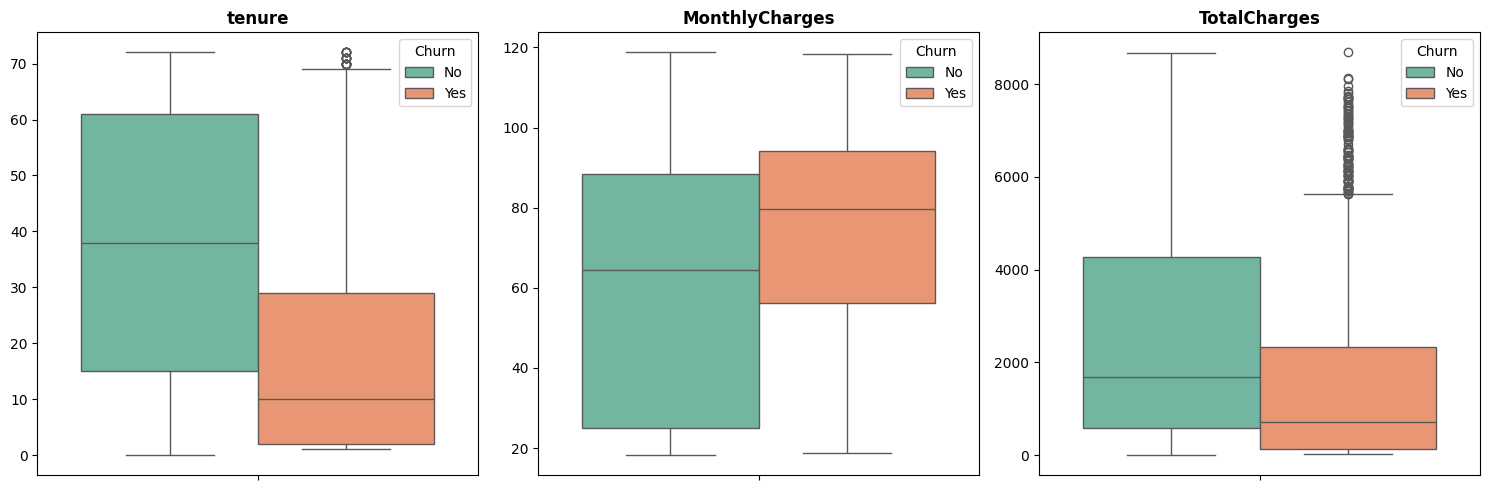

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
axes_flat = ax.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=data, y=col, hue='Churn', ax=axes_flat[i], palette='Set2')
    axes_flat[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes_flat[i].set_xlabel('')
    axes_flat[i].set_ylabel('')

for j in range(len(num_cols), len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.tight_layout()
plt.show()

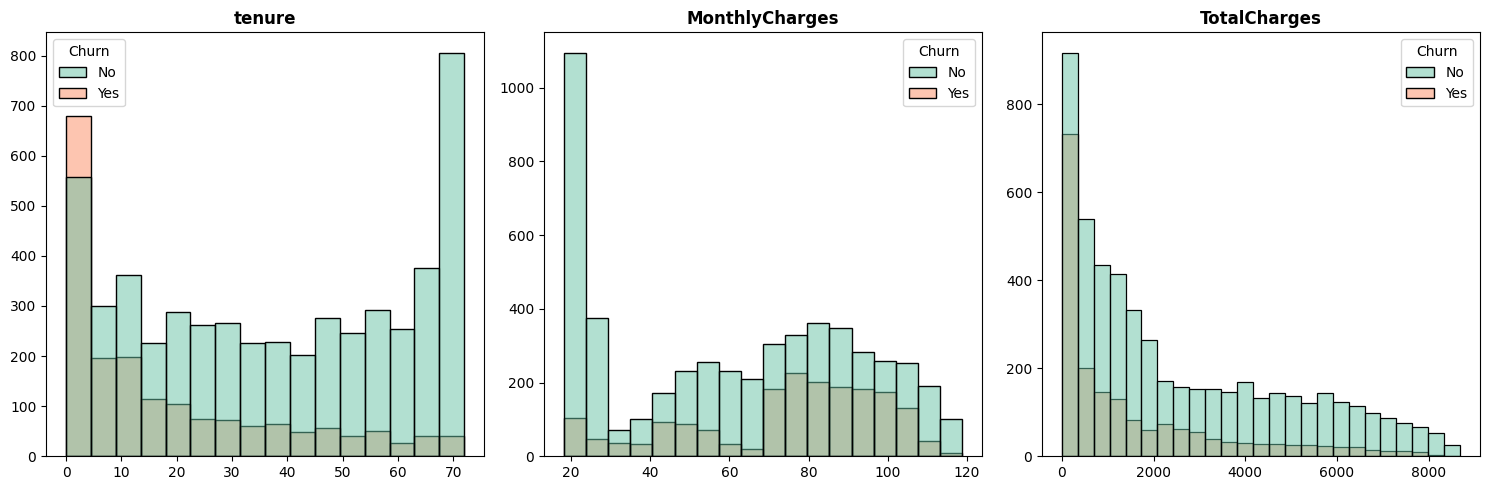

In [18]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
axes_flat = ax.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=data, x=col, hue='Churn', ax=axes_flat[i], palette='Set2')
    axes_flat[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes_flat[i].set_xlabel('')
    axes_flat[i].set_ylabel('')

for j in range(len(num_cols), len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.tight_layout()
plt.show()

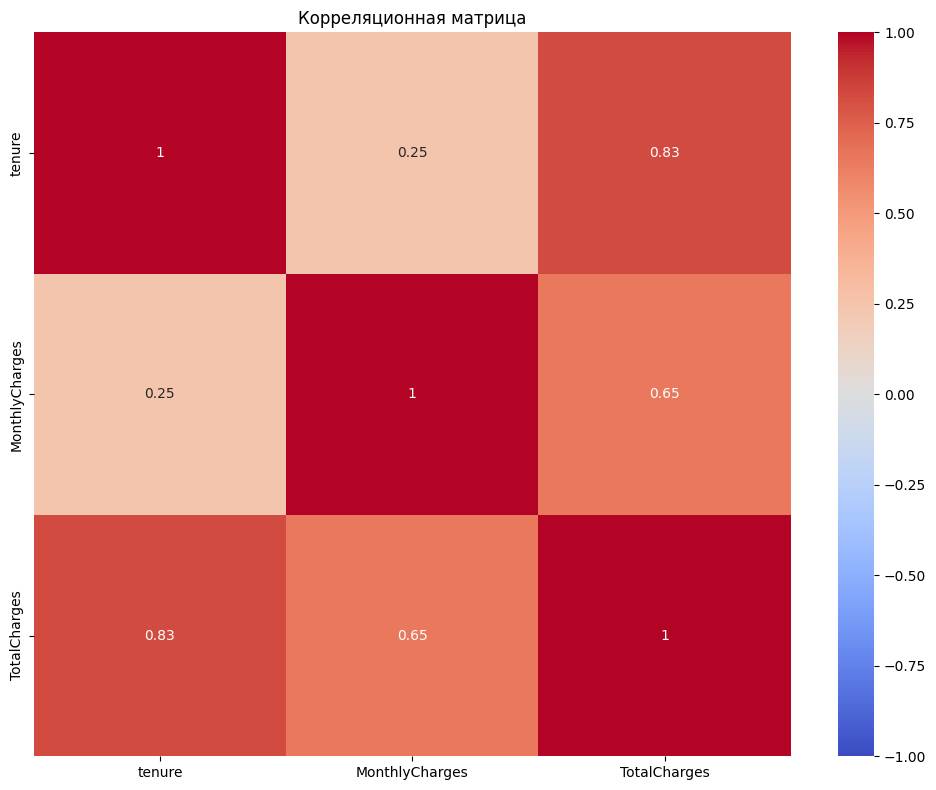

In [19]:
plt.figure(figsize=(10, 8))
correlation_matrix = data.select_dtypes(include='number').corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.show()

### Вывод:
- Есть умеренный дисбаланс классов ~73%/26% (Использование метода SMOTE не даст улучшения качества)
- Наличие дополнительных услуг у клиента (InternetService, OnlineSecurity, OnlineBackup, TechSupport) снижает риск оттока.
- Тип контракта month-to-month повышает риск ухода клиента
- Пользователи с типом оплаты Electronic check уходят чаще
- Новые пользователи с нулевым сроком обслуживания (tenure) и сответственно без платежей больше склонны уходить
- Есть высокая корреляция между tenure и TotalCharges (0.8), а так же между MonthlyCharges и TotalCharges (0.65) (Возможно будет влиять на линейные модели, для древесных - не кретично)
- Сильных выбросов нет